In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *


IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 783885


In [2]:
'''
Create vegetation land masks
'''
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

box = [(32,55),(232,256)]

In [14]:
'''
MAIN function for performing optimal fingerprinting using cam5 and ERA5
'''

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }

vege_mask_flag = True
d4PDF_BC_flag = True

explained_var_dict = {}

for i,model in enumerate(['d4pdf','cam5']):

        
    if model == 'cam5':
        scen_dict = {'ALL':'All','NAT':'Nat'}
        range_dict = {'start':'1959','end':'2014'}
        vege_mask = cam5_vege_mask
    if model == 'd4pdf':
        scen_dict = {'ALL':'HPB','NAT':'HPB_NAT'}
        range_dict = {'start':'1951','end':'2021'}
        vege_mask = d4pdf_vege_mask
        
    IDL.retall

    print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise(model, scen_dict['ALL'], box, vege_mask_flag, range_dict['start'], range_dict['end'],d4PDF_BC_flag)
    print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise(model, scen_dict['NAT'], box, vege_mask_flag, range_dict['start'], range_dict['end'],d4PDF_BC_flag)

    print('getting obs')
    data_obs = get_obs_data(model, box, vege_mask, vege_mask_flag, range_dict['start'], range_dict['end'],d4PDF_BC_flag)
    print('got obs')
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    if model == 'cam5':
        data_noise_1 = np.concatenate((noise_all[:22],noise_nat[:24]))
        data_noise_2 = np.concatenate((noise_all[22:],noise_nat[24:]))

    else:
        data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
        data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))
        
    print('got arrays')

    if model == 'cam5':
        trunc = np.array([i for i in range(3,44)])
    if model == 'd4pdf':
        trunc = np.array([i for i in range(3,98)])
        
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.scan_beta_est = []
    IDL.scan_p_resid = []
    IDL.noise_singval=[]
    
    print('running gendetec')
    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, scan_resid_sumsq=scan_resid_sumsq, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, scan_beta_est=scan_beta_est,\
            scan_p_resid=scan_p_resid,noise_singval=noise_singval")

    scan_beta_est = IDL.scan_beta_est
    scan_p_resid = IDL.scan_p_resid
    noise_singval = IDL.noise_singval
    
    explained_var_dict[model] = noise_singval

    #print(scan_beta_est)
    



getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec
getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays
running gendetec


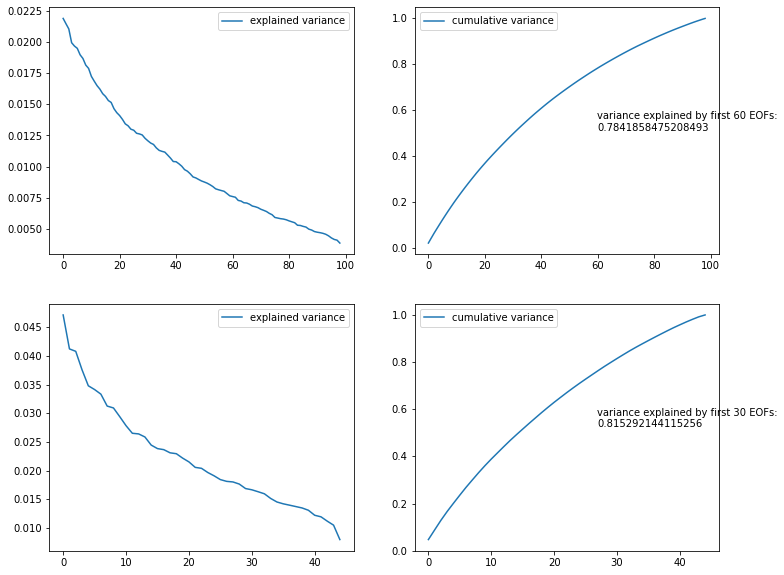

In [24]:
trunc_dict = {'cam5': np.array([i for i in range(3,44)]),
              'd4pdf':np.array([i for i in range(3,98)])}

fig,axs = plt.subplots(2,2,figsize=(12,10))

for i,model in enumerate(['d4pdf','cam5']):
    
    noise_singval = explained_var_dict[model]
    squared = noise_singval**2

    variance = []
    for val in squared:
        variance.append(val/sum(squared))

    cum_variance = np.cumsum(variance)
    
    axs[i][0].plot(variance,label='explained variance')
    axs[i][1].plot(cum_variance,label='cumulative variance')
    
    if model == 'd4pdf':
        axs[i][1].text(0.6,0.5,f'variance explained by first 60 EOFs:\n{cum_variance[60]}',transform=axs[i][1].transAxes)

    if model == 'cam5':
        axs[i][1].text(0.6,0.5,f'variance explained by first 30 EOFs:\n{cum_variance[30]}',transform=axs[i][1].transAxes)
        
    axs[i][0].legend()
    axs[i][1].legend()

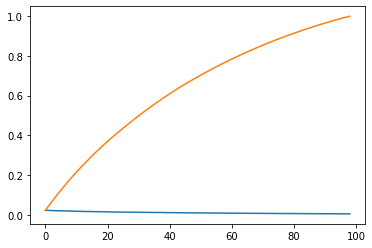

In [13]:
plt.plot(variance)
plt.plot(cum_variance)

In [4]:
def get_obs_data(model, box, vege_mask, vege_mask_flag, start_year, end_year, d4PDF_BC=True):
    
    if model == 'cam5':
        model_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
    else:
        if d4PDF_BC:
            model_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
        else:
            model_da = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_HPB_ensMean.nc')

        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')

    if box != 'full':
        era5_da = era5_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        era5_da = era5_da.where(vege_mask>0)
        
    era5_da = era5_da.sel(time=slice(start_year,end_year))
    era5_da = era5_da.where(~model_da.isnull())
    
    era5_da = era5_da.stack(pixel=("latitude", "longitude"))
    era5_da = era5_da.dropna("pixel", how="all")        
    
    array = era5_da.values.flatten()
    
    #del era5_da
    
    return(array)


In [5]:
def get_noise_premade(model,era5_da,scen,ens_mean,box,vege_mask_flag,start_year,end_year):
    
    if model == 'cam5':
        runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
                'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}
    else:
        runs = {'HPB':range(1,101),
                'HPB_NAT':range(1,101)}
    noise = []
    for ens_mem in runs[scen]:
        
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        if model == 'cam5':
            diff = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/FWI_noise_'+scen+'_run'+number+'.nc')
        else:
            diff = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/FWI_noise_'+scen+'_m'+number+'.nc')

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
    return(noise)


In [6]:
def get_noise(model,era5_da,scen,ens_mean,box,vege_mask_flag,start_year,end_year,d4PDF_BC=True):
    
    if model == 'cam5':
        runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
                'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}
    else:
        runs = {'HPB':range(1,101),
                'HPB_NAT':range(1,101)}
    noise = []
    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        if model == 'cam5':
            mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_run'+number+'.nc')
        elif model == 'd4pdf':
            if d4PDF_BC:
                mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_m'+number+'.nc')
            else:
                mem_da = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_'+scen+'_m'+number+'.nc')

        if box != 'full':
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        if vege_mask_flag:
            mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice(start_year,end_year))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
    return(noise)


In [7]:
def get_mean_and_noise(model, scen, box, vege_mask_flag, start_year, end_year, d4PDF_BC=True):
    
    if model == 'cam5':
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
        ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_ensMean.nc')
    else:
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
        
        if d4PDF_BC:
            ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_ensMean.nc')
        else:
            ens_mean = xr.open_dataarray('/nesi/project/niwa02986/queenle/data/d4pdf/WNAmerica/FWI/6m_fire_season/FWI_'+scen+'_ensMean.nc')
    
    if box != 'full':
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    if vege_mask_flag:
        ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice(start_year,end_year))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = get_noise(model,era5_da,scen,ens_mean,box,vege_mask_flag,start_year,end_year)

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()
    
    return((ens_mean_array, np.array(noise)))
